In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.ndimage import maximum_filter
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────

ROOT      = Path("..")  # repo root
BASIN_DIR = ROOT / "seam_basin"

DATASET = "benzene_s0"   # butadiene_s0 | butadiene_s1 | benzene_s0 | benzene_s1

# KDE bandwidth — None = CV selection, float = fixed
BANDWIDTH = None

# 3D Grid-based peak finding
N_GRID         = 200    # grid resolution per axis (80^3 points)
MIN_PEAK_DIST  = 5     # minimum separation between peaks in grid cells
PEAK_THRESHOLD = 0.005  # discard peaks below this fraction of global max

# Plot settings
PAD_FRAC         = 0.2
SCATTER_S        = 6
SCATTER_ALPHA    = 0.7
MECI_S           = 250
BASIN_S          = 150
DENSITY_CMAP     = "viridis"
TICK_SIZE        = 13
LABEL_SIZE       = 15
TITLE_SIZE       = 16
FIG_W, FIG_H     = 8, 7

SAVE = True
DPI  = 300

In [3]:
# ── Load 3D embeddings ───────────────────────────────────────────────────────

out_dir   = BASIN_DIR / DATASET
emb_spawn = np.load(out_dir / "spawn_embedding_3d.npy")   # (N_spawn, 3)
emb_meci  = np.load(out_dir / "meci_embedding_3d.npy")    # (N_meci,  3)
meci_df   = pd.read_csv(out_dir / "meci_metrics_grid_3d.csv")
meci_names = meci_df["meci"].tolist()

print(f"Spawns: {len(emb_spawn)}  |  MECIs: {len(emb_meci)}  |  Dims: {emb_spawn.shape[1]}")

Spawns: 3657  |  MECIs: 5  |  Dims: 3


In [4]:
# ── Fit KDE on 3D spawn embedding (cached to disk) ─────────────────────────
import pickle, hashlib

cache_path = out_dir / f"kde_cache_bw{str(BANDWIDTH)}.pkl"

if cache_path.exists():
    with open(cache_path, "rb") as f:
        cache = pickle.load(f)
    kde, bw, spawn_density = cache["kde"], cache["bw"], cache["spawn_density"]
    print(f"Loaded KDE from cache (bw={bw:.4f})")
else:
    if BANDWIDTH is None:
        params = {"bandwidth": np.logspace(-2, 1, 20)}
        grid_cv = GridSearchCV(KernelDensity(), params, cv=5)
        grid_cv.fit(emb_spawn)
        bw = grid_cv.best_params_["bandwidth"]
        print(f"CV-selected bandwidth: {bw:.4f}")
    else:
        bw = BANDWIDTH
        print(f"Using fixed bandwidth: {bw:.4f}")
    kde = KernelDensity(bandwidth=bw, kernel="gaussian").fit(emb_spawn)
    spawn_density = np.exp(kde.score_samples(emb_spawn))
    spawn_density /= spawn_density.sum()
    with open(cache_path, "wb") as f:
        pickle.dump({"kde": kde, "bw": bw, "spawn_density": spawn_density}, f)
    print(f"KDE fitted and cached -> {cache_path}")

CV-selected bandwidth: 0.5456
KDE fitted and cached -> ../seam_basin/benzene_s0/kde_cache_bwNone.pkl


In [5]:
# ── Build 3D KDE grid and find peaks (cached to disk) ──────────────────────
import pickle

grid_cache_path = out_dir / f"kde_grid_cache_bw{bw:.4f}_n{N_GRID}.npy"
axes_cache_path = out_dir / f"kde_grid_axes_bw{bw:.4f}_n{N_GRID}.pkl"

if grid_cache_path.exists() and axes_cache_path.exists():
    zz3d = np.load(grid_cache_path)
    with open(axes_cache_path, "rb") as f:
        axes_1d = pickle.load(f)
    print(f"Loaded grid from cache: {grid_cache_path}")
else:
    axes_1d = []
    for d in range(3):
        lo, hi = emb_spawn[:, d].min(), emb_spawn[:, d].max()
        p = (hi - lo) * 0.05
        axes_1d.append(np.linspace(lo - p, hi + p, N_GRID))
    grids    = np.meshgrid(*axes_1d, indexing="ij")
    grid_pts = np.column_stack([g.ravel() for g in grids])
    zz3d     = np.exp(kde.score_samples(grid_pts)).reshape([N_GRID] * 3)
    np.save(grid_cache_path, zz3d)
    with open(axes_cache_path, "wb") as f:
        pickle.dump(axes_1d, f)
    print(f"Grid computed and cached -> {grid_cache_path}")

fp        = np.ones([MIN_PEAK_DIST * 2 + 1] * 3)
local_max = (maximum_filter(zz3d, footprint=fp) == zz3d)
local_max &= zz3d >= PEAK_THRESHOLD * zz3d.max()

peak_idx = np.argwhere(local_max)
modes    = np.array([[axes_1d[d][idx[d]] for d in range(3)] for idx in peak_idx])

print(f"Grid-based maxima: {len(modes)}")

Grid computed and cached -> ../seam_basin/benzene_s0/kde_grid_cache_bw0.5456_n200.npy
Grid-based maxima: 5


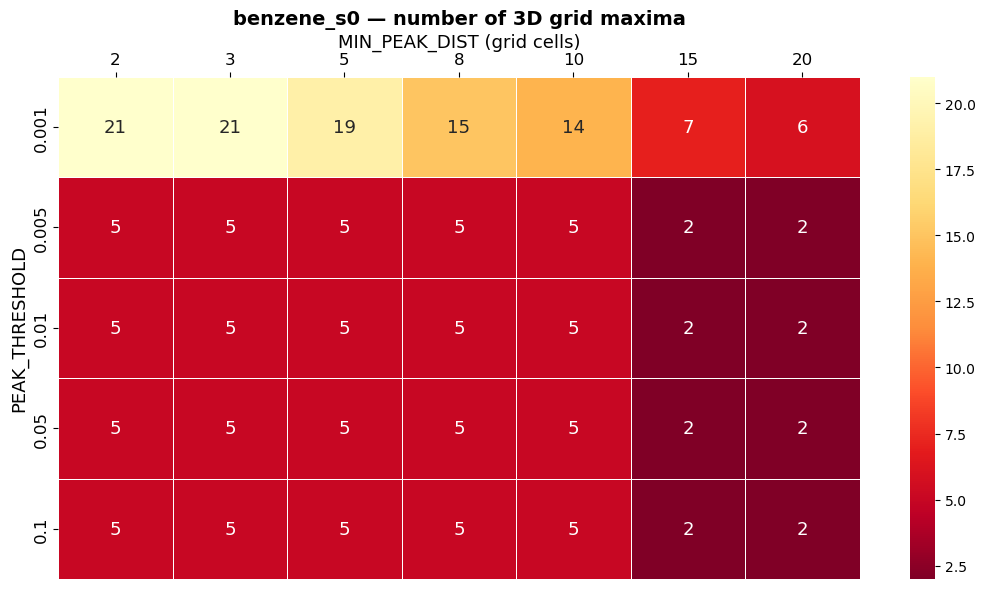

In [6]:
# ── Parameter sweep: basin count heatmap (MIN_PEAK_DIST x PEAK_THRESHOLD) ───

SWEEP_MIN_DIST  = [2, 3, 5, 8, 10, 15, 20]
SWEEP_THRESHOLD = [0.001, 0.005, 0.01, 0.05, 0.1]

counts = np.zeros((len(SWEEP_THRESHOLD), len(SWEEP_MIN_DIST)), dtype=int)
for i, thr in enumerate(SWEEP_THRESHOLD):
    for j, md in enumerate(SWEEP_MIN_DIST):
        fp = np.ones([md * 2 + 1] * 3)
        lm = (maximum_filter(zz3d, footprint=fp) == zz3d) & (zz3d >= thr * zz3d.max())
        counts[i, j] = lm.sum()

fig, ax = plt.subplots(figsize=(len(SWEEP_MIN_DIST) * 1.4 + 1, len(SWEEP_THRESHOLD) + 1))
sns.heatmap(counts, annot=True, fmt="d",
            xticklabels=SWEEP_MIN_DIST, yticklabels=SWEEP_THRESHOLD,
            cmap="YlOrRd_r", linewidths=0.5, ax=ax, annot_kws={"size": 13})
ax.set_xlabel("MIN_PEAK_DIST (grid cells)", fontsize=13)
ax.set_ylabel("PEAK_THRESHOLD", fontsize=13)
ax.set_title(f"{DATASET} — number of 3D grid maxima", fontsize=14, fontweight="bold")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

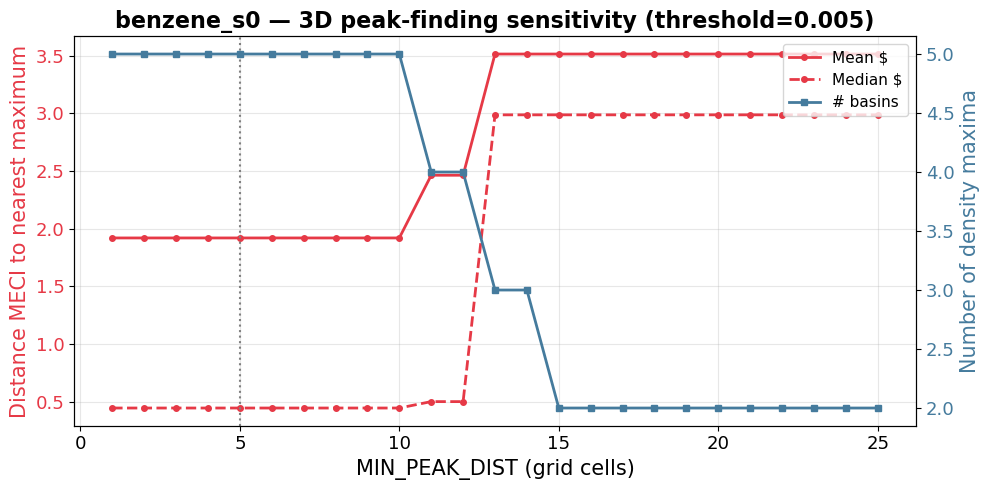

In [7]:
# ── Scoring curve: mean d_m and basin count vs MIN_PEAK_DIST (3D) ───────────

SCORE_MIN_DISTS = list(range(1, 26))
SCORE_THRESHOLD = PEAK_THRESHOLD

n_basins_list, mean_dm_list, median_dm_list = [], [], []

for md in SCORE_MIN_DISTS:
    fp    = np.ones([md * 2 + 1] * 3)
    lm    = (maximum_filter(zz3d, footprint=fp) == zz3d) & (zz3d >= SCORE_THRESHOLD * zz3d.max())
    peaks = np.array([[axes_1d[d][idx[d]] for d in range(3)] for idx in np.argwhere(lm)])

    if len(peaks) == 0:
        n_basins_list.append(0); mean_dm_list.append(np.nan); median_dm_list.append(np.nan)
        continue

    dists = np.linalg.norm(emb_meci[:, None, :] - peaks[None, :, :], axis=2)
    dm    = dists.min(axis=1)
    n_basins_list.append(len(peaks))
    mean_dm_list.append(dm.mean())
    median_dm_list.append(np.median(dm))

fig, ax1 = plt.subplots(figsize=(10, 5))
color_dm, color_count = "#e63946", "#457b9d"

ax1.plot(SCORE_MIN_DISTS, mean_dm_list,   color=color_dm, lw=2, marker="o", ms=4, label="Mean $")
ax1.plot(SCORE_MIN_DISTS, median_dm_list, color=color_dm, lw=2, marker="o", ms=4, ls="--", label="Median $")
ax1.set_xlabel("MIN_PEAK_DIST (grid cells)", fontsize=LABEL_SIZE)
ax1.set_ylabel("Distance MECI to nearest maximum", fontsize=LABEL_SIZE, color=color_dm)
ax1.tick_params(axis="y", labelcolor=color_dm, labelsize=TICK_SIZE)
ax1.tick_params(axis="x", labelsize=TICK_SIZE)

ax2 = ax1.twinx()
ax2.plot(SCORE_MIN_DISTS, n_basins_list, color=color_count, lw=2, marker="s", ms=4, label="# basins")
ax2.set_ylabel("Number of density maxima", fontsize=LABEL_SIZE, color=color_count)
ax2.tick_params(axis="y", labelcolor=color_count, labelsize=TICK_SIZE)

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], fontsize=11, loc="upper right")
ax1.axvline(MIN_PEAK_DIST, color="gray", ls=":", lw=1.5)
ax1.set_title(f"{DATASET} — 3D peak-finding sensitivity (threshold={SCORE_THRESHOLD})",
              fontsize=TITLE_SIZE, fontweight="bold")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig("eth_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Saved -> ../seam_basin/benzene_s0/density_scatter_3d_nb.png
Saved -> ../seam_basin/benzene_s0/density_scatter_3d_nb.svg


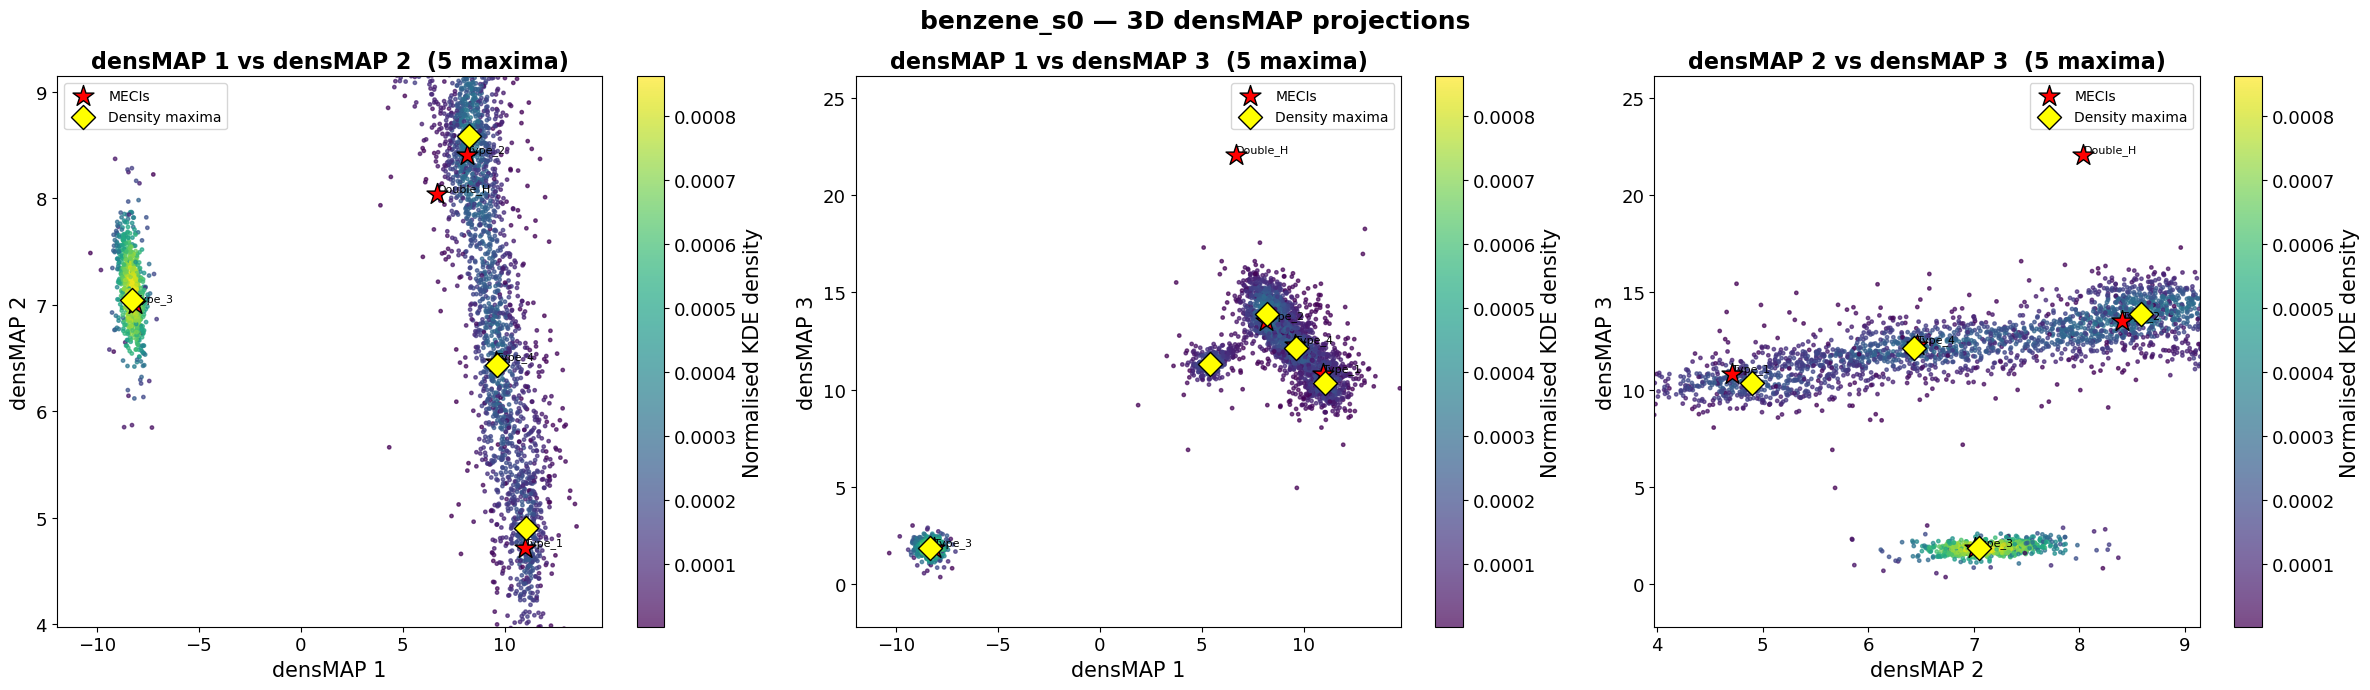

In [8]:
# ── Pairwise 2D projections of 3D embedding ──────────────────────────────────

LABELS = ["densMAP 1", "densMAP 2", "densMAP 3"]
pairs  = list(itertools.combinations(range(3), 2))

fig, axes = plt.subplots(1, 3, figsize=(FIG_W * 3, FIG_H))

for ax, (xi, yi) in zip(axes, pairs):
    sc = ax.scatter(emb_spawn[:, xi], emb_spawn[:, yi],
                    c=spawn_density, s=SCATTER_S, alpha=SCATTER_ALPHA,
                    cmap=DENSITY_CMAP, rasterized=True)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(labelsize=TICK_SIZE)
    cbar.set_label("Normalised KDE density", size=LABEL_SIZE)
    ax.scatter(emb_meci[:, xi], emb_meci[:, yi],
               marker="*", s=MECI_S, c="red", edgecolor="k", zorder=5, label="MECIs")
    ax.scatter(modes[:, xi], modes[:, yi],
               marker="D", s=BASIN_S, c="yellow", edgecolor="k", zorder=5, label="Density maxima")
    for i, name in enumerate(meci_names):
        ax.annotate(name, (emb_meci[i, xi], emb_meci[i, yi]), fontsize=8, ha="left", va="bottom")
    xlo, xhi = emb_meci[:, xi].min(), emb_meci[:, xi].max()
    ylo, yhi = emb_meci[:, yi].min(), emb_meci[:, yi].max()
    xpad = (xhi - xlo) * PAD_FRAC or 1.0
    ypad = (yhi - ylo) * PAD_FRAC or 1.0
    ax.set_xlim(xlo - xpad, xhi + xpad)
    ax.set_ylim(ylo - ypad, yhi + ypad)
    ax.set_xlabel(LABELS[xi], fontsize=LABEL_SIZE)
    ax.set_ylabel(LABELS[yi], fontsize=LABEL_SIZE)
    ax.set_title(f"{LABELS[xi]} vs {LABELS[yi]}  ({len(modes)} maxima)",
                 fontsize=TITLE_SIZE, fontweight="bold")
    ax.tick_params(labelsize=TICK_SIZE)
    ax.legend(fontsize=10)

fig.suptitle(f"{DATASET} — 3D densMAP projections", fontsize=TITLE_SIZE + 2, fontweight="bold")
plt.tight_layout()
if SAVE:
    for ext in ["png", "svg"]:
        p = out_dir / f"density_scatter_3d_nb.{ext}"
        plt.savefig(p, dpi=DPI, bbox_inches="tight")
        print(f"Saved -> {p}")
plt.show()

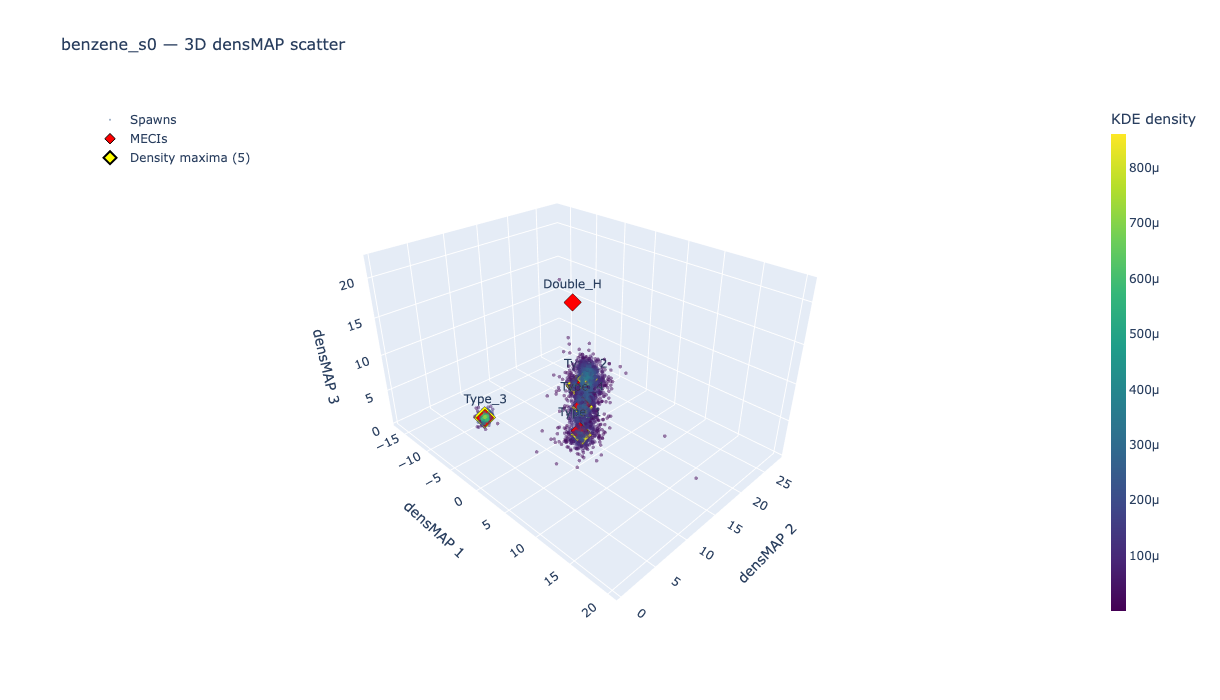

In [10]:
# ── Interactive 3D scatter: spawns + MECIs + density maxima ─────────────────
import plotly.graph_objects as go

fig_s3d = go.Figure()

# Spawn points coloured by KDE density
fig_s3d.add_trace(go.Scatter3d(
    x=emb_spawn[:, 0], y=emb_spawn[:, 1], z=emb_spawn[:, 2],
    mode="markers",
    marker=dict(
        size=2,
        color=spawn_density,
        colorscale="Viridis",
        opacity=0.5,
        colorbar=dict(title="KDE density", thickness=15, x=1.02),
    ),
    name="Spawns",
))

# MECIs
fig_s3d.add_trace(go.Scatter3d(
    x=emb_meci[:, 0], y=emb_meci[:, 1], z=emb_meci[:, 2],
    mode="markers+text",
    marker=dict(size=8, color="red", symbol="diamond",
                line=dict(color="black", width=1)),
    text=meci_names,
    textposition="top center",
    name="MECIs",
))

# Density maxima
fig_s3d.add_trace(go.Scatter3d(
    x=modes[:, 0], y=modes[:, 1], z=modes[:, 2],
    mode="markers",
    marker=dict(size=10, color="yellow", symbol="diamond",
                line=dict(color="black", width=2)),
    name=f"Density maxima ({len(modes)})",
))

fig_s3d.update_layout(
    title=dict(text=f"{DATASET} — 3D densMAP scatter", font=dict(size=16)),
    scene=dict(
        xaxis_title="densMAP 1",
        yaxis_title="densMAP 2",
        zaxis_title="densMAP 3",
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2)),
    ),
    width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig_s3d.show()

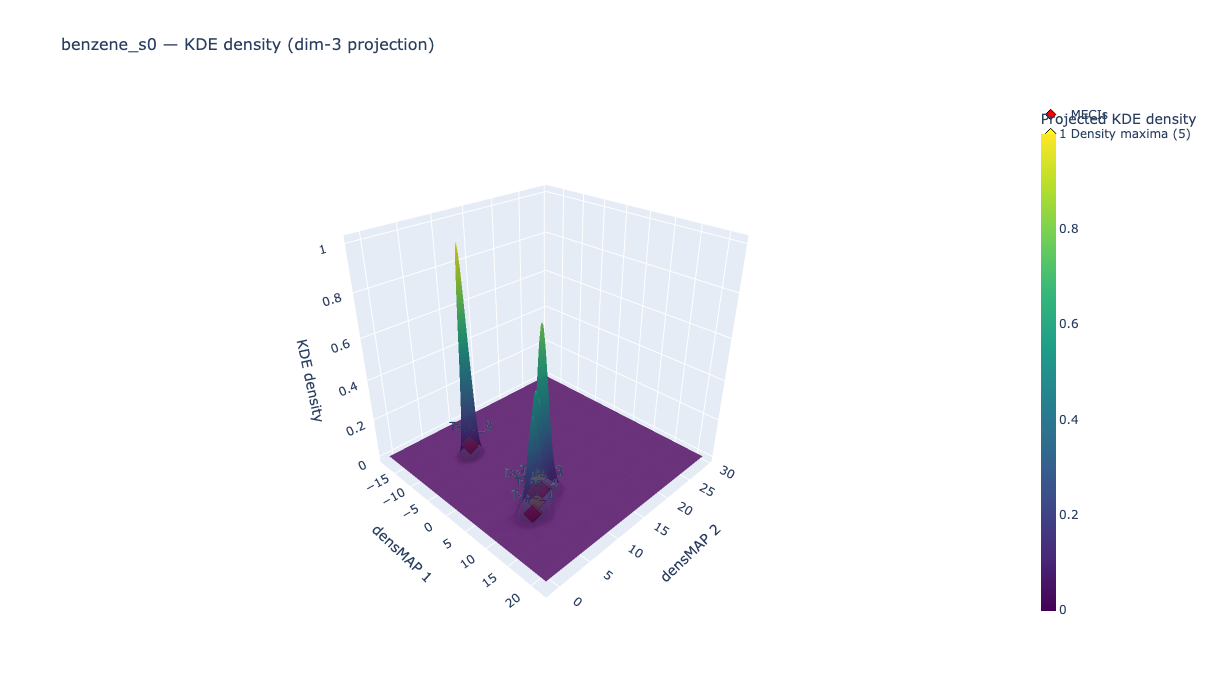

In [11]:
# ── Interactive 3D KDE surface (plotly) ─────────────────────────────────────
# pip install plotly  if needed

import plotly.graph_objects as go

# Marginalise over dim 3 for the background surface
zz2d_proj = zz3d.sum(axis=2)
zz2d_proj /= zz2d_proj.max()

fig3d = go.Figure()
fig3d.add_trace(go.Surface(
    x=axes_1d[0], y=axes_1d[1], z=zz2d_proj.T,
    colorscale="Viridis", opacity=0.85,
    colorbar=dict(title="Projected KDE density", thickness=15),
))
meci_z_proj = np.exp(kde.score_samples(emb_meci))
fig3d.add_trace(go.Scatter3d(
    x=emb_meci[:, 0], y=emb_meci[:, 1], z=meci_z_proj * 1.05,
    mode="markers+text",
    marker=dict(size=8, color="red", symbol="diamond", line=dict(color="black", width=1)),
    text=meci_names, textposition="top center", name="MECIs",
))
modes_z = np.exp(kde.score_samples(modes))
fig3d.add_trace(go.Scatter3d(
    x=modes[:, 0], y=modes[:, 1], z=modes_z * 1.05,
    mode="markers",
    marker=dict(size=8, color="yellow", symbol="diamond", line=dict(color="black", width=1)),
    name=f"Density maxima ({len(modes)})",
))
fig3d.update_layout(
    title=dict(text=f"{DATASET} — KDE density (dim-3 projection)", font=dict(size=16)),
    scene=dict(xaxis_title="densMAP 1", yaxis_title="densMAP 2", zaxis_title="KDE density",
               camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2))),
    width=900, height=700,
)
fig3d.show()

In [12]:
# ── MECI metrics summary ─────────────────────────────────────────────────────

dists   = np.linalg.norm(emb_meci[:, None, :] - modes[None, :, :], axis=2)
nearest = np.argmin(dists, axis=1)
d_m     = dists[np.arange(len(emb_meci)), nearest]
assign  = np.argmin(np.linalg.norm(emb_spawn[:, None, :] - modes[None, :, :], axis=2), axis=1)
N_k     = {k: int(np.sum(assign == k)) for k in range(len(modes))}
rho_m   = np.exp(kde.score_samples(emb_meci)) / np.exp(kde.score_samples(emb_spawn)).sum()

summary = pd.DataFrame({
    "meci":          meci_names,
    "rho_m":         rho_m,
    "nearest_basin": nearest,
    "d_m":           d_m,
    "basin_N_k":     [N_k[b] for b in nearest],
})
print(f"Dataset: {DATASET}  |  Bandwidth: {bw:.4f}  |  Basins: {len(modes)}")
print(f"MIN_PEAK_DIST={MIN_PEAK_DIST}  PEAK_THRESHOLD={PEAK_THRESHOLD}")
display(summary.sort_values("rho_m", ascending=False).reset_index(drop=True))

basin_summary = pd.DataFrame({
    "basin_id":   list(N_k.keys()),
    "N_k":        list(N_k.values()),
    "centroid_x": modes[:, 0],
    "centroid_y": modes[:, 1],
    "centroid_z": modes[:, 2],
})
print("Basin populations:")
display(basin_summary.sort_values("N_k", ascending=False).reset_index(drop=True))

Dataset: benzene_s0  |  Bandwidth: 0.5456  |  Basins: 5
MIN_PEAK_DIST=5  PEAK_THRESHOLD=0.005


,meci,rho_m,nearest_basin,d_m,basin_N_k
0,Type_3,8.409364e-04,0,0.163040,807
1,Type_2,3.488000e-04,2,0.444035,1046
2,Type_4,3.086753e-04,3,0.173986,849
3,Type_1,2.287999e-04,4,0.499680,608
4,Double_H,2.028923e-23,2,8.318508,1046


Basin populations:


,basin_id,N_k,centroid_x,centroid_y,centroid_z
0,2,1046,8.230505,8.577698,13.917606
1,3,849,9.641533,6.432599,12.134999
2,0,807,-8.298693,7.045485,1.835492
3,4,608,11.052563,4.900386,10.352392
4,1,347,5.408445,9.803468,11.342730
